# Air Quality Index (AQI) Prediction in India using Machine Learning

This notebook conducts a comprehensive analysis of air quality data in India and builds various regression models to predict the Air Quality Index (AQI). The workflow includes downloading and loading the dataset, data cleaning, exploratory data analysis (EDA), temporal feature engineering, data visualization, model selection, ensemble modeling, and hyperparameter tuning using Grid Search.

### 1. Import Necessary Libraries and Packages

We start by importing all the required Python libraries for data manipulation, numerical computations, visualization, modeling, and evaluation.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression  , Lasso ,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # Needed for HistGB
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,
                              AdaBoostRegressor ,GradientBoostingRegressor,HistGradientBoostingRegressor
                              , VotingRegressor,StackingRegressor)
import xgboost as xgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,accuracy_score
from sklearn.impute import SimpleImputer
from tqdm import tqdm


### 2. Download the Dataset from Kaggle

We download the latest version of the Air Quality Data in India dataset from Kaggle via the `kagglehub` package.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Path to dataset files:", path)

c:\Users\Naseer\anaconda3\envs\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Naseer\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12


### 3. Identify Dataset CSV File

We print the path of the downloaded file to locate the main `city_day.csv` file.

In [5]:
print(path+"/city_day.csv")

C:\Users\Naseer\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12/city_day.csv


### 4. Read the Dataset into a Pandas DataFrame

We load the CSV file into a pandas DataFrame named `city_day` to inspect and analyze the dataset.

In [ ]:
city_day = pd.read_csv(path+'/city_day.csv')

### 5. Inspect the Dataset Shape

We check the total number of rows and columns in the `city_day` dataset.

In [7]:
print("Dataset Shape :")
print(f"City_day : {city_day.shape}")

Dataset Shape :
City_day : (29531, 16)


### 6. Exploratory Data Analysis (EDA): Data Preview

We print the first 10 rows of the dataset to get an overview of the columns and sample data values.

In [10]:
print("=" * 80)
print("City day Dataset")
print("=" * 80 )
city_day.head(10)

City day Dataset


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


### 7. Dataset Column Information

We inspect column data types, memory footprint, and check for the counts of non-null values.

In [11]:
print("=" * 80)
print("Information about Dataset")
print("=" * 80 )
city_day.info()

Information about Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


### 8. Basic Statistical Summary

We compute statistical measures (such as mean, std, min, max, and quantiles) for all numerical features.

In [12]:
print("=" * 80)
print("Basic Statistics")
print("=" * 80 )
city_day.describe()

Basic Statistics


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


### 9. Identify Null and Missing Values

Let's see which features have missing values and calculate their counts.

In [17]:
print("=" * 80)
print("Missing Value")
print("=" * 80 )
city_day.isnull().sum()

Missing Value


City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

### 10. Copy Dataset for Preprocessing

We make a copy of the dataset before applying transformations and feature engineering.

In [18]:
df = city_day.copy()


### 11. Feature Engineering: Date Extraction

We parse the date column and extract temporal features: Year, Month, Day, Day of Week, and Quarter.

In [20]:
df['Date']=pd.to_datetime(df['Date'])
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day
df['DayOfweek']=df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

### 12. Preview Data with Engineered Features

Let's preview the first few rows to verify the successful creation of temporal columns.

In [21]:
df.head(5)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,DayOfweek,Quarter
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,...,0.00,0.02,0.00,NaN,NaN,2015,1,1,3,1
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,...,3.68,5.50,3.77,NaN,NaN,2015,1,2,4,1
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,...,6.80,16.40,2.25,NaN,NaN,2015,1,3,5,1
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,...,4.43,10.14,1.00,NaN,NaN,2015,1,4,6,1
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,...,7.01,18.89,2.78,NaN,NaN,2015,1,5,0,1


### 13. Inspect Unique Cities

We determine the total number of unique cities in the dataset and list their names.

In [22]:
print(df["City"].nunique())
df["City"].unique()

26


array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

### 14. Check Unique AQI Bucket Categories

We display the unique text labels representing AQI classification levels.

In [23]:
print(df['AQI_Bucket'].unique())


[nan 'Poor' 'Very Poor' 'Severe' 'Moderate' 'Satisfactory' 'Good']


### 15. Dataset Shape After Feature Engineering

Let's check the size of the DataFrame now that new columns have been added.

In [ ]:
df.shape #after feature engineering

(29531, 21)

### 16. Missing Value Analysis

We check the top columns with missing values to decide on cleaning and imputation strategies.

In [31]:
print(df.isnull().sum().sort_values(ascending=False).head(15))

Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
City              0
dtype: int64


### 17. Prepare Missing Values for Visualization

We extract missing value data and filter out columns with 100% complete data.

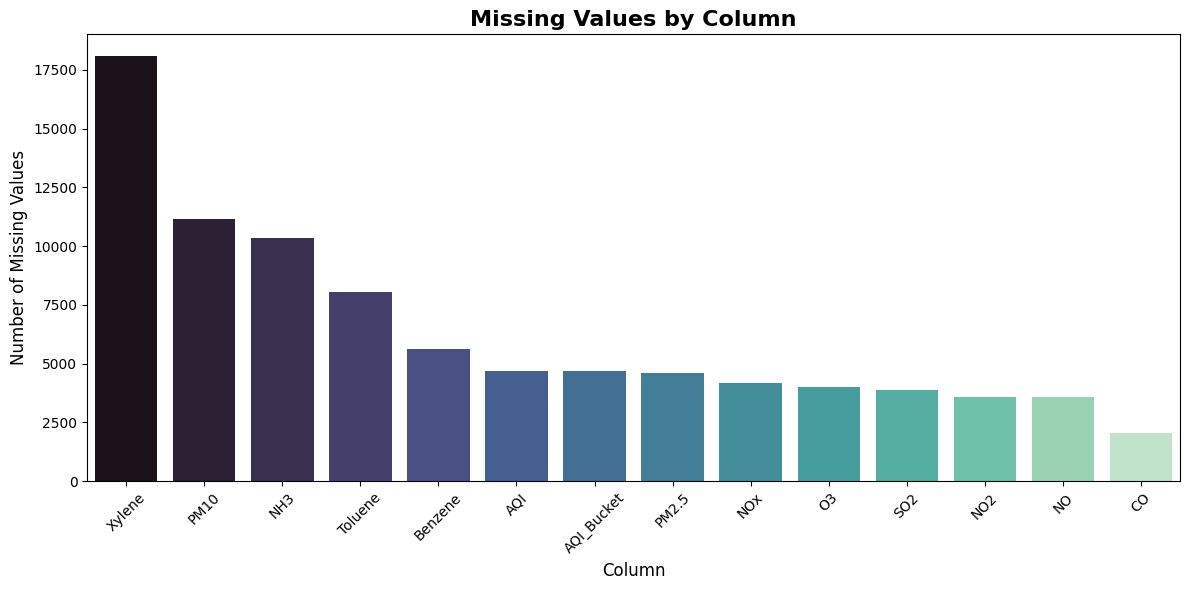

In [38]:
missing_df = df.isnull().sum().sort_values(ascending=False).reset_index()
missing_df.columns = ['Column', 'Missing_Values']

missing_df = missing_df[missing_df['Missing_Values'] > 0]

plt.figure(figsize=(12,6))
sns.barplot(data=missing_df, x='Column', y='Missing_Values', palette='mako')

plt.title('Missing Values by Column', fontsize=16, fontweight='bold')
plt.xlabel('Column', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 18. Visualize AQI Distribution

We display the distribution of AQI values using a histogram and mark the average AQI value.

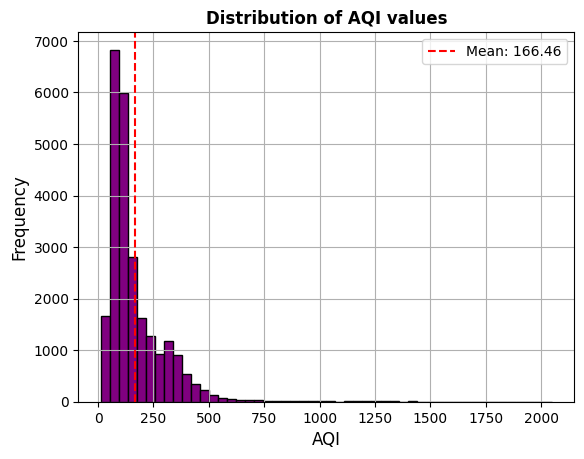

In [44]:
plt.hist(df['AQI'].dropna(),bins=50,color='Purple',edgecolor='black')
plt.title('Distribution of AQI values',fontsize=12,fontweight='bold')
plt.xlabel('AQI',fontsize=12)
plt.ylabel('Frequency',fontsize=12)
plt.axvline(df['AQI'].mean(),color='red',linestyle='--',label=f'Mean: {df["AQI"].mean():.2f}')
plt.legend()
plt.grid()
plt.show()

### 19. Analyze AQI Classification Buckets

We draw a bar chart to visualize the distribution of different air quality classifications.

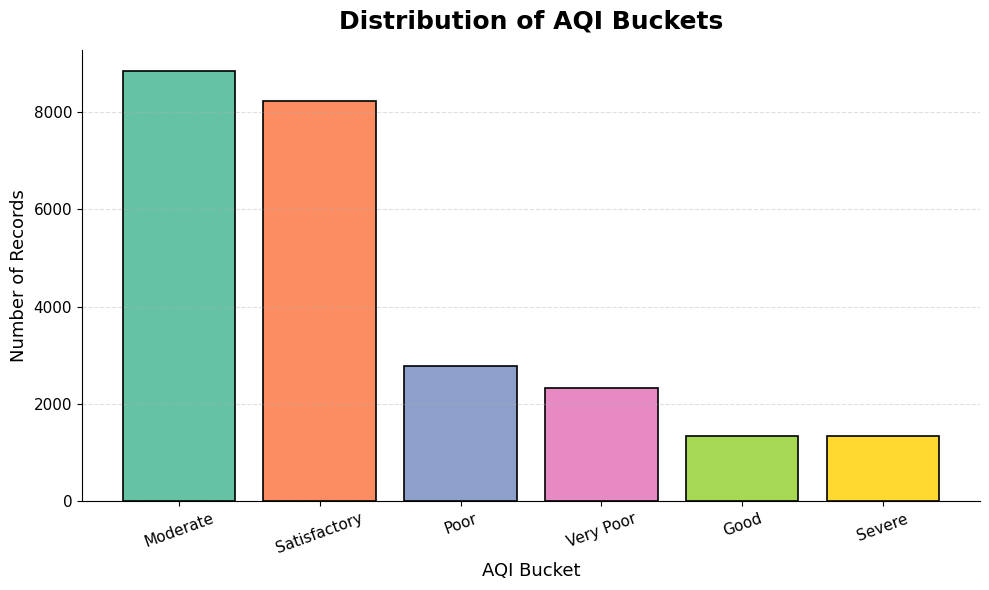

In [54]:
qi_bucket_counts = df['AQI_Bucket'].value_counts()

plt.figure(figsize=(10,6))

bars = plt.bar(
    qi_bucket_counts.index,
    qi_bucket_counts.values,
    color=plt.cm.Set2.colors[:len(qi_bucket_counts)],
    edgecolor='black',
    linewidth=1.2
)



plt.title('Distribution of AQI Buckets', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('AQI Bucket', fontsize=13)
plt.ylabel('Number of Records', fontsize=13)

plt.xticks(rotation=20, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

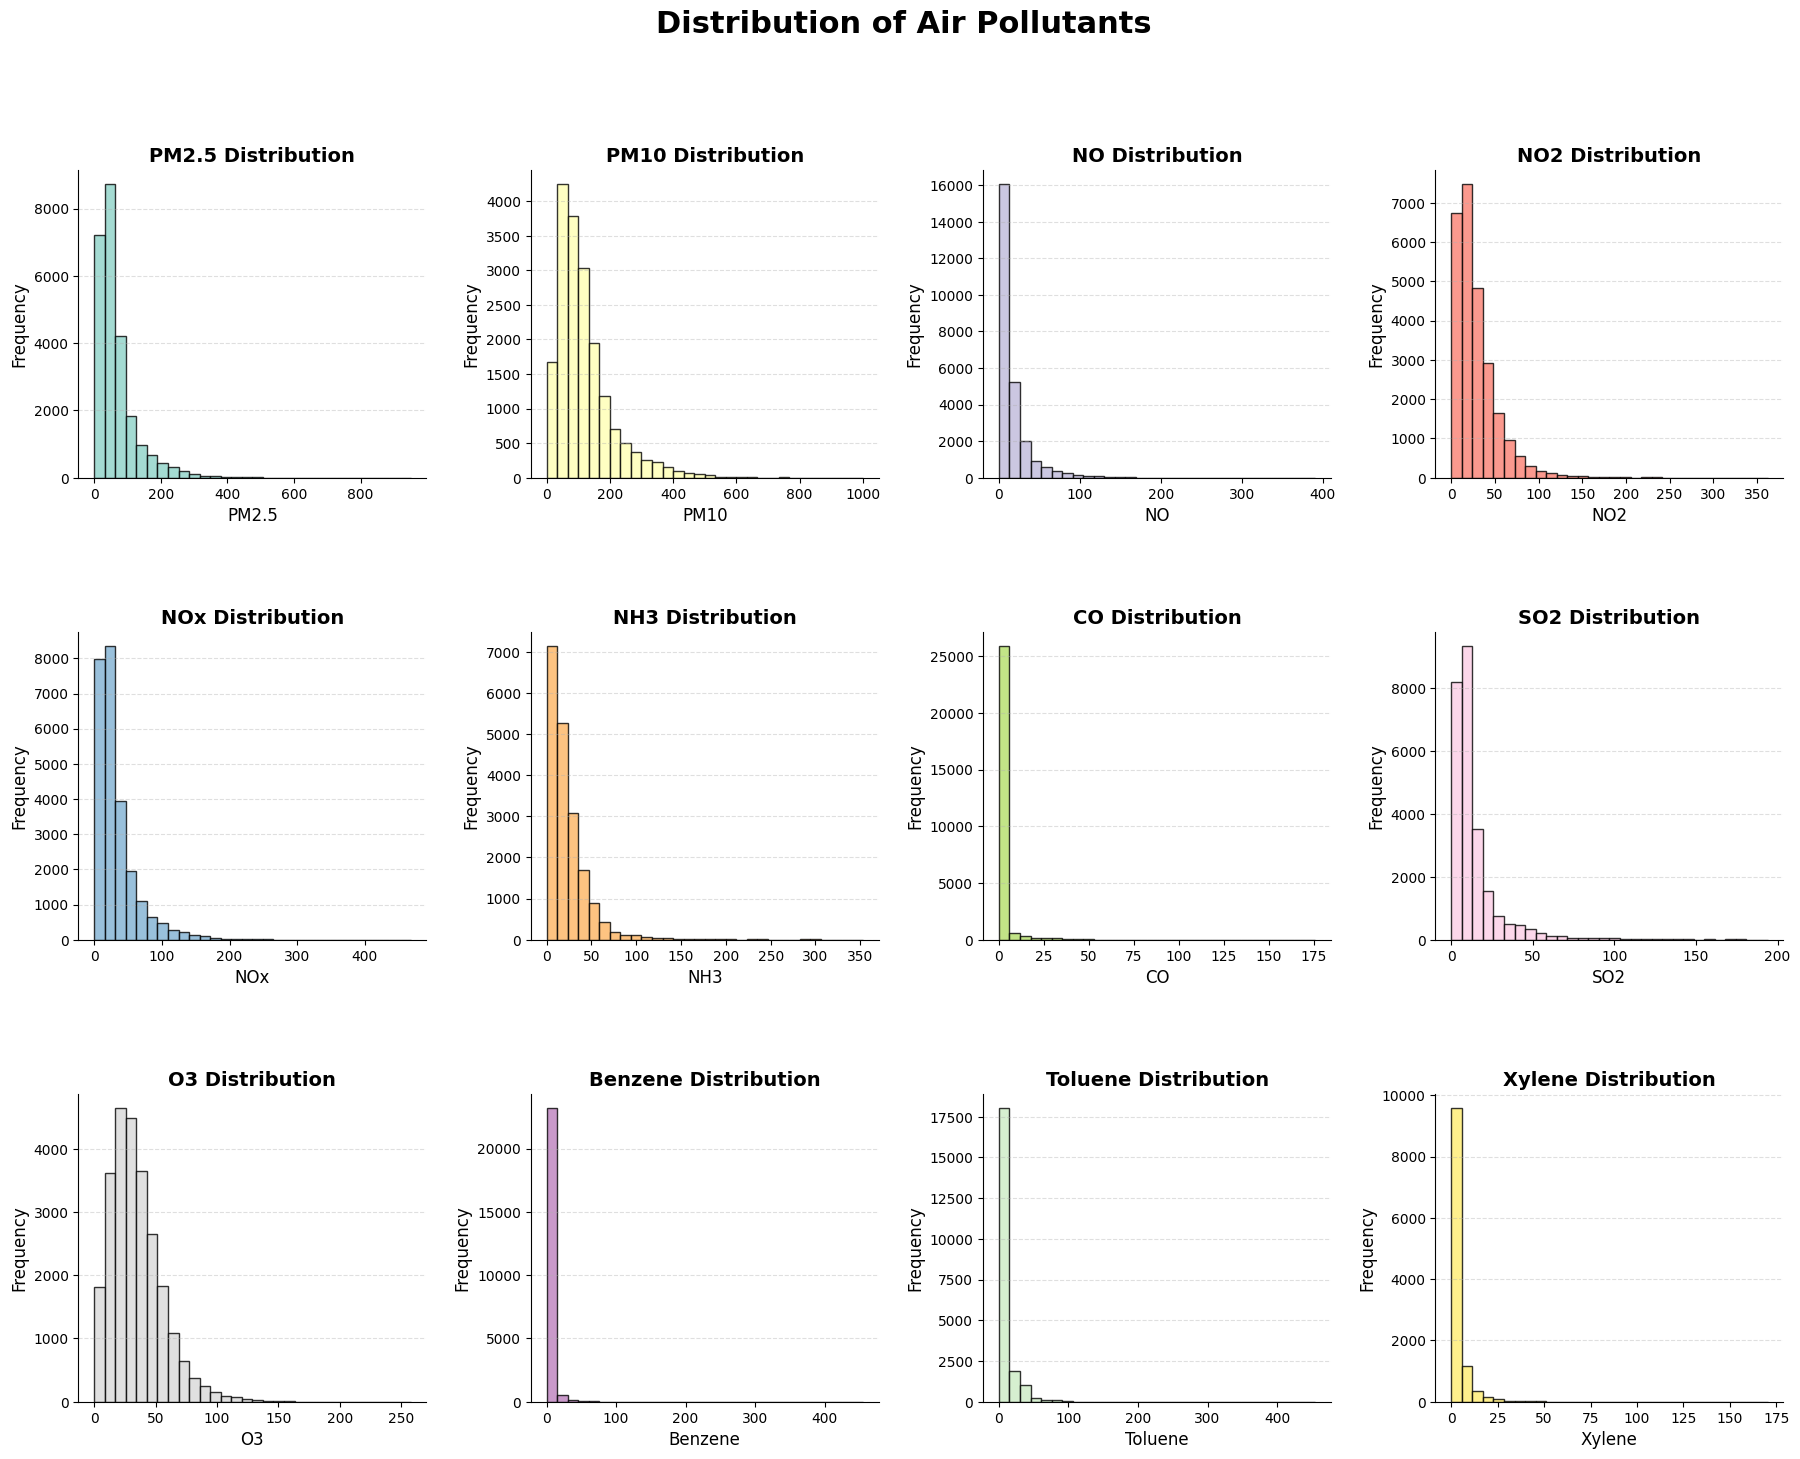

In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
              'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

available_pollutants = [
    p for p in pollutants
    if p in df.columns and df[p].notna().sum() > 100
]

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

colors = plt.cm.Set3.colors

for idx, pollutant in enumerate(available_pollutants):
    ax = axes[idx]

    ax.hist(
        df[pollutant].dropna(),
        bins=30,
        color=colors[idx % len(colors)],
        edgecolor='black',
        alpha=0.8
    )

    ax.set_title(f'{pollutant} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel(pollutant, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for i in range(len(available_pollutants), len(axes)):
    axes[i].axis('off')

fig.suptitle(
    'Distribution of Air Pollutants',
    fontsize=22,
    fontweight='bold'
)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

### 20. Correlation Analysis Heatmap

We compute correlation coefficients between all numerical features and visualize them with a heatmap.

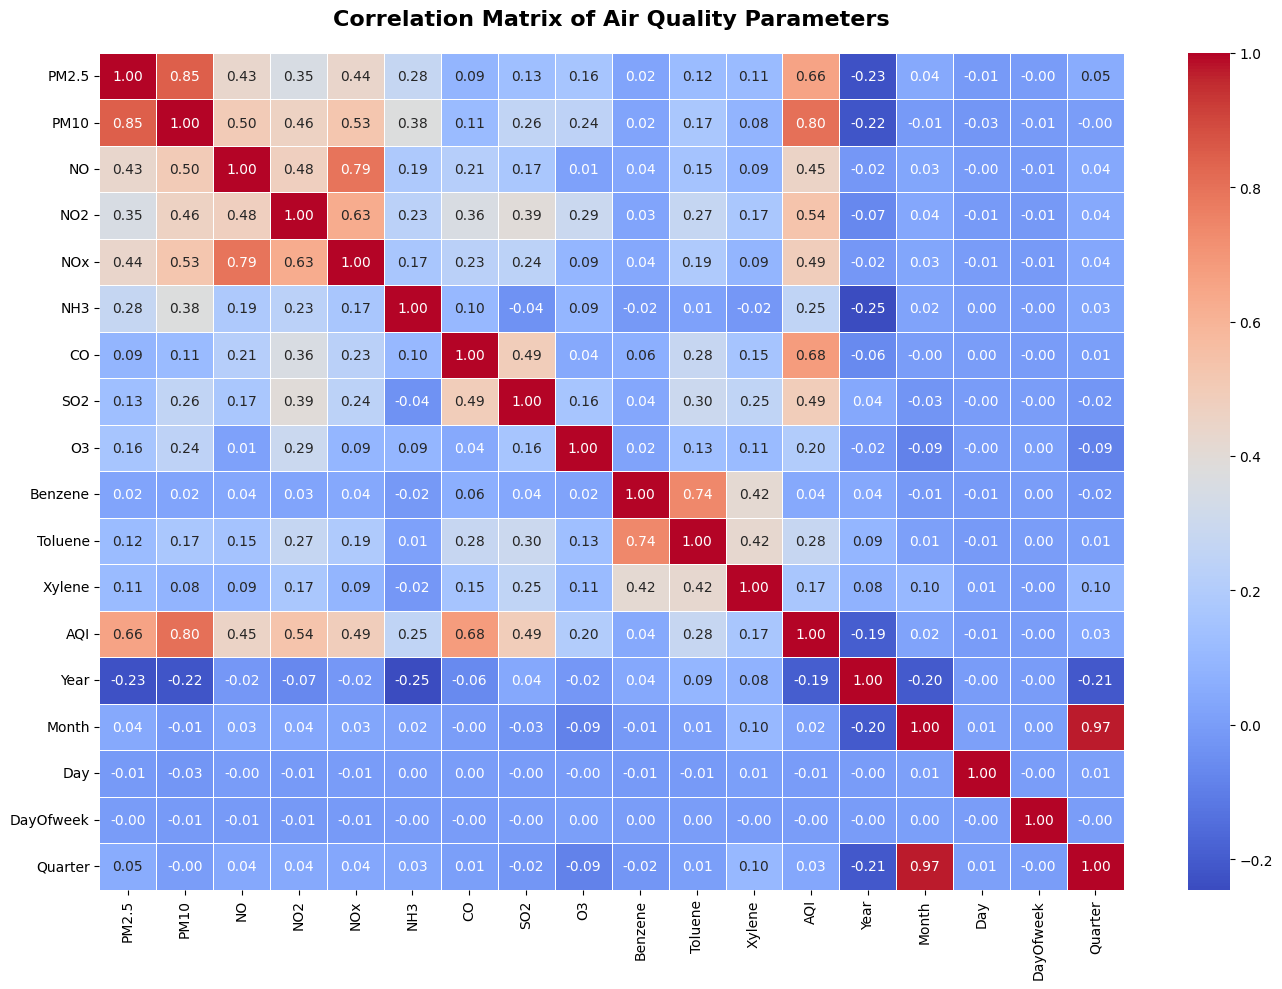

In [58]:
numaric_df = df.select_dtypes(include=[np.number]).columns
cor_mat=df[numaric_df].corr()

plt.figure(figsize=(14,10))
sns.heatmap(cor_mat,annot=True,fmt='.2f',cmap="coolwarm",linewidths=0.5)
plt.title('Correlation Matrix of Air Quality Parameters', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 21. Feature Correlations with AQI

We extract and sort the correlation coefficients of all predictor variables with the target variable `AQI`.

In [62]:
if 'AQI' in cor_mat.columns:
    aqi_cor = cor_mat['AQI'].sort_values(ascending=False)
    print("\nCorrelation with AQI:")
    print(aqi_cor[1:])


Correlation with AQI:
PM10         0.803313
CO           0.683346
PM2.5        0.659181
NO2          0.537071
SO2          0.490586
NOx          0.486450
NO           0.452191
Toluene      0.279992
NH3          0.252019
O3           0.198991
Xylene       0.165532
Benzene      0.044407
Quarter      0.032031
Month        0.022163
DayOfweek   -0.000210
Day         -0.005582
Year        -0.192464
Name: AQI, dtype: float64


### 22. Time-Series Analysis: AQI Trends Over Time

We plot average daily AQI values over time to examine long-term variations and trends.

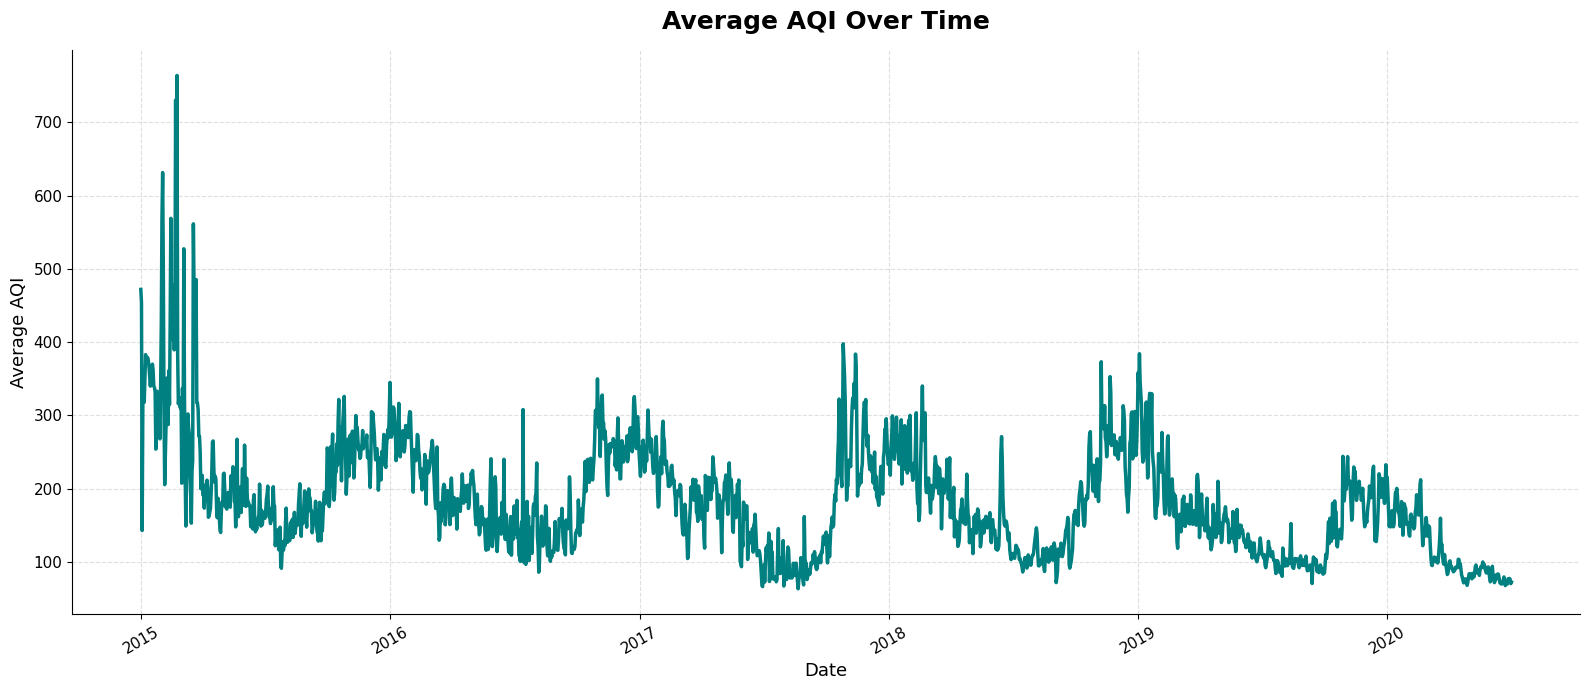

In [66]:
df_time = df.groupby('Date')['AQI'].mean().reset_index()

plt.figure(figsize=(16, 7))

plt.plot(
    df_time['Date'],
    df_time['AQI'],
    color='teal',
    linewidth=2.5,
    markersize=4
)

plt.title('Average AQI Over Time', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Average AQI', fontsize=13)

plt.xticks(fontsize=11, rotation=30)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 23. Monthly Aggregated AQI Average

We resample our AQI values on a monthly basis to smooth daily fluctuations.

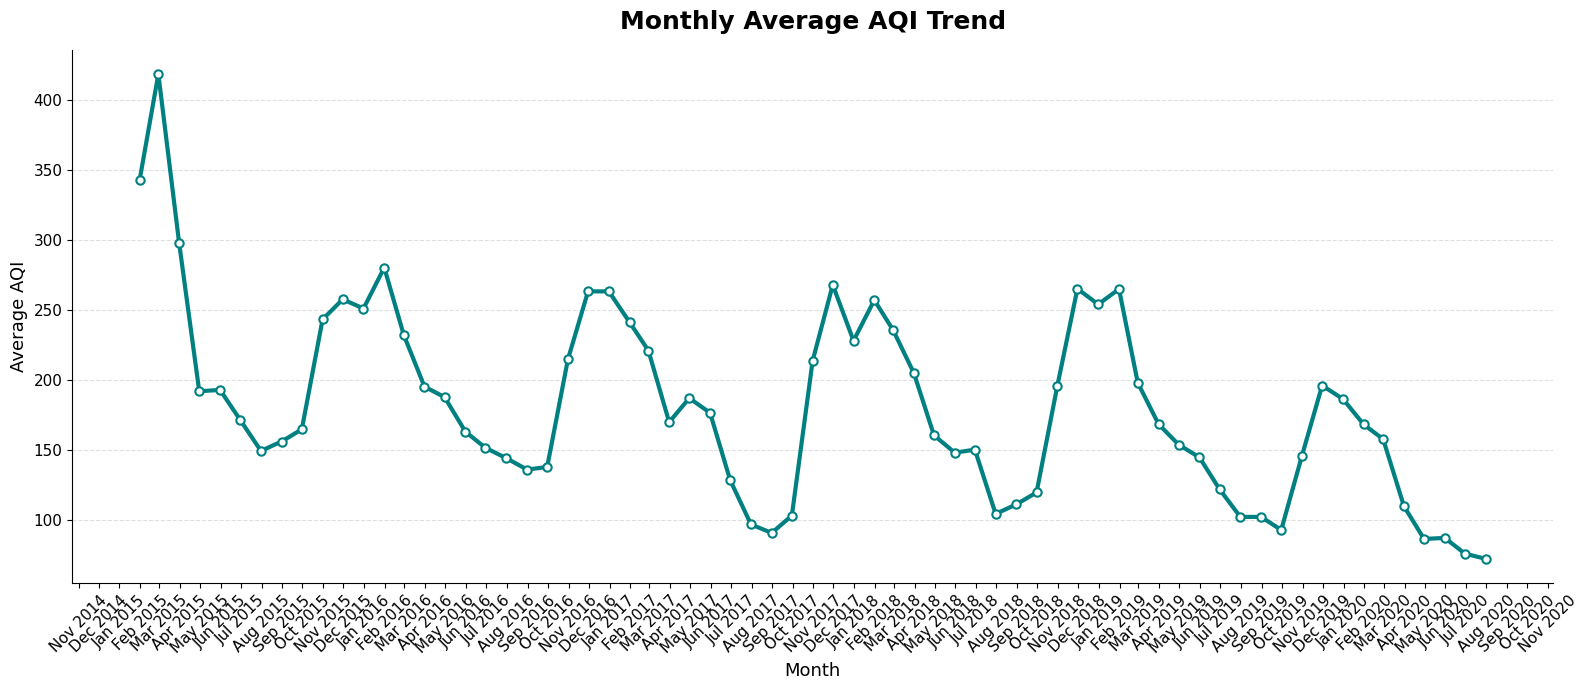

In [ ]:
import matplotlib.dates as mdates

df = df.sort_values('Date')
monthly_aqi = df.resample('M', on='Date')['AQI'].mean()

plt.figure(figsize=(16,7))

plt.plot(
    monthly_aqi.index,
    monthly_aqi.values,
    color='teal',
    linewidth=3,
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgewidth=1.5
)

plt.title(
    'Monthly Average AQI Trend',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Month', fontsize=13)
plt.ylabel('Average AQI', fontsize=13)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [70]:
# import matplotlib.dates as mdates

# df = df.sort_values('Date')

# yearly_aqi = df.resample('YE', on='Date')['AQI'].mean()

# plt.figure(figsize=(14,6))

# plt.plot(
#     yearly_aqi.index,
#     yearly_aqi.values,
#     color='teal',
#     linewidth=3,
#     marker='o',
#     markersize=7
# )

# plt.title('Yearly Average AQI Trend', fontsize=18, fontweight='bold')
# plt.xlabel('Year', fontsize=13)
# plt.ylabel('Average AQI', fontsize=13)

# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# plt.xticks(fontsize=11)
# plt.yticks(fontsize=11)

# plt.grid(axis='y', linestyle='--', alpha=0.4)

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# plt.tight_layout()
# plt.show()

### 24. Analyze Monthly Average AQI Trends

We plot the monthly average AQI across the dataset to discover regular seasonal patterns.

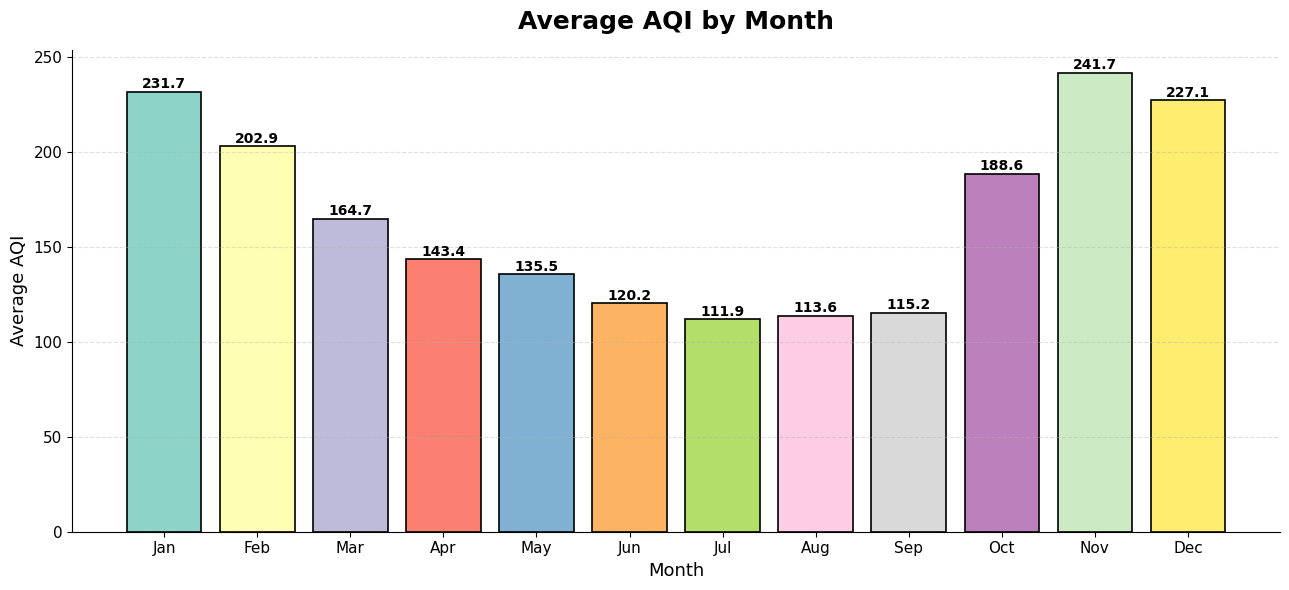

In [73]:
monthly_aqi = df.groupby('Month')['AQI'].mean().reset_index()

plt.figure(figsize=(13,6))

bars = plt.bar(
    monthly_aqi['Month'],
    monthly_aqi['AQI'],
    color=plt.cm.Set3.colors[:12],
    edgecolor='black',
    linewidth=1.2
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{bar.get_height():.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Average AQI by Month', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=13)
plt.ylabel('Average AQI', fontsize=13)

plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    fontsize=11
)

plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 25. Top 20 Most Polluted Cities

We calculate the mean AQI for each city and plot the top 20 cities with the highest average index values.

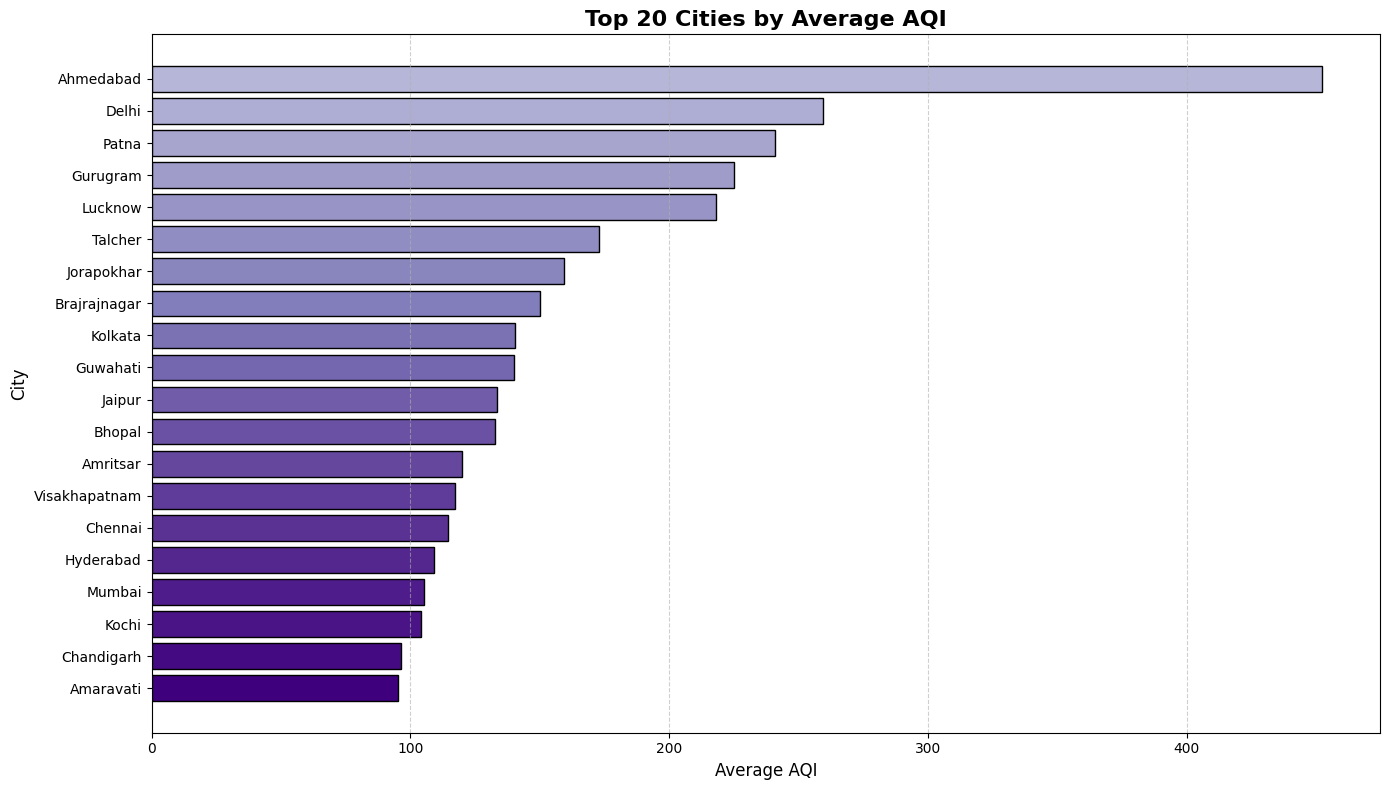

In [77]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 8))

colors = plt.cm.Purples(np.linspace(0.4, 1, len(city_aqi)))

bars = plt.barh(city_aqi.index,
                city_aqi.values,
                color=colors,
                edgecolor='black')

plt.title('Top 20 Cities by Average AQI', fontsize=16, fontweight='bold')
plt.xlabel('Average AQI', fontsize=12)
plt.ylabel('City', fontsize=12)

plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 26. AQI Spread in Top 10 Most Polluted Cities

We use boxplots to inspect the distribution, variance, and outliers of AQI values for the top 10 most polluted cities.

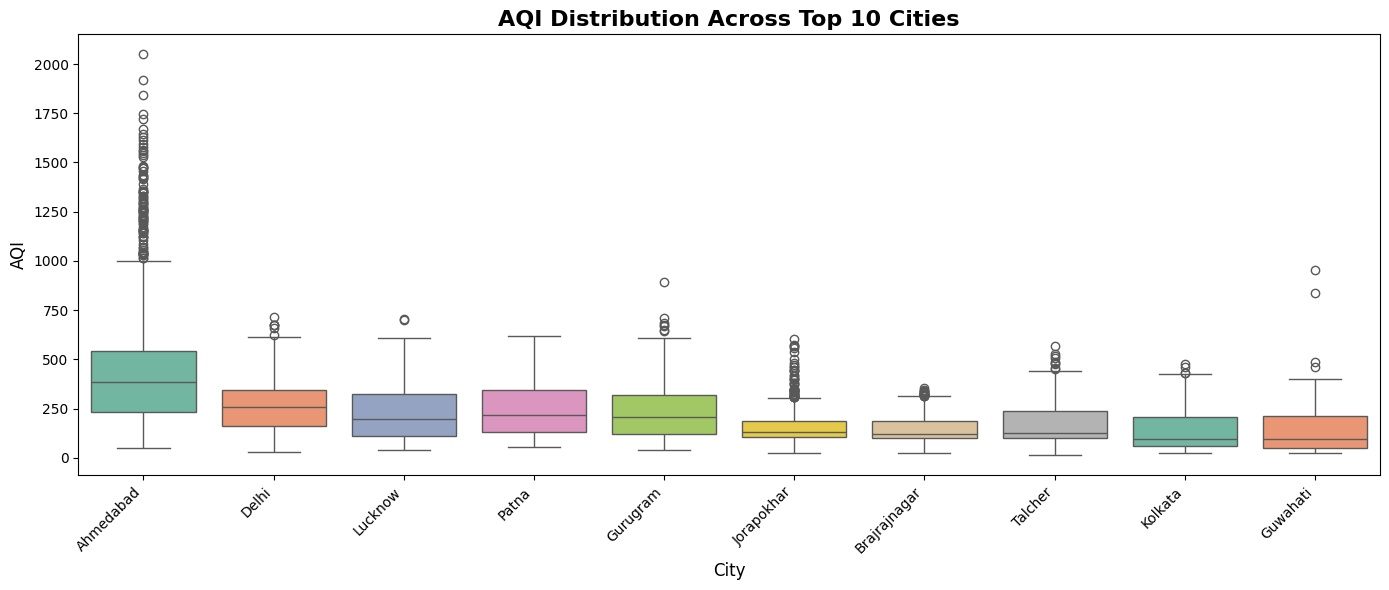

In [78]:
top_city=city_aqi.head(10).index
df_top=df[df['City'].isin(top_city)]
plt.figure(figsize=(14,6))
sns.boxplot(data=df_top,x='City',y='AQI',palette='Set2')
plt.title('AQI Distribution Across Top 10 Cities', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 27. Annual Average AQI Changes

We visualize annual average AQI trends to check for changes over the years.

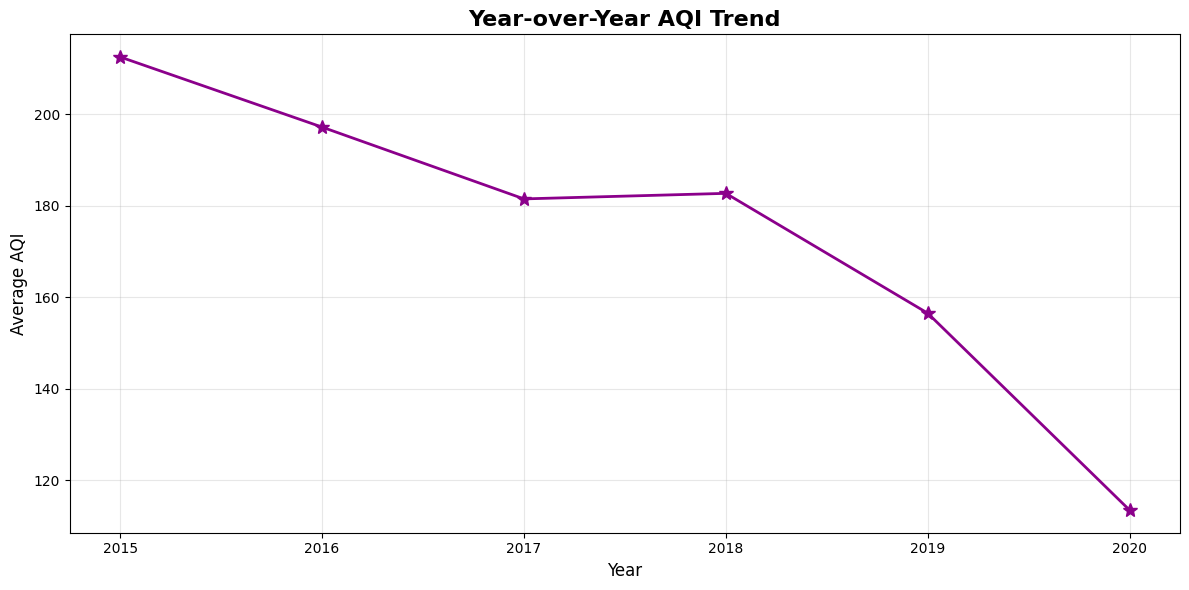


Yearly AQI Summary:
   Year         AQI
0  2015  212.463054
1  2016  197.150019
2  2017  181.472789
3  2018  182.684312
4  2019  156.518173
5  2020  113.520697


In [79]:
yearly_aqi = df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(yearly_aqi['Year'], yearly_aqi['AQI'], marker='*', linewidth=2, 
         markersize=10, color='darkmagenta')
plt.title('Year-over-Year AQI Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_aqi['Year'])
plt.tight_layout()
plt.show()

print("\nYearly AQI Summary:")
print(yearly_aqi)

### 28. Evolution of AQI Classifications Month by Month

We visualize how the distribution of AQI categories evolves on a monthly basis.

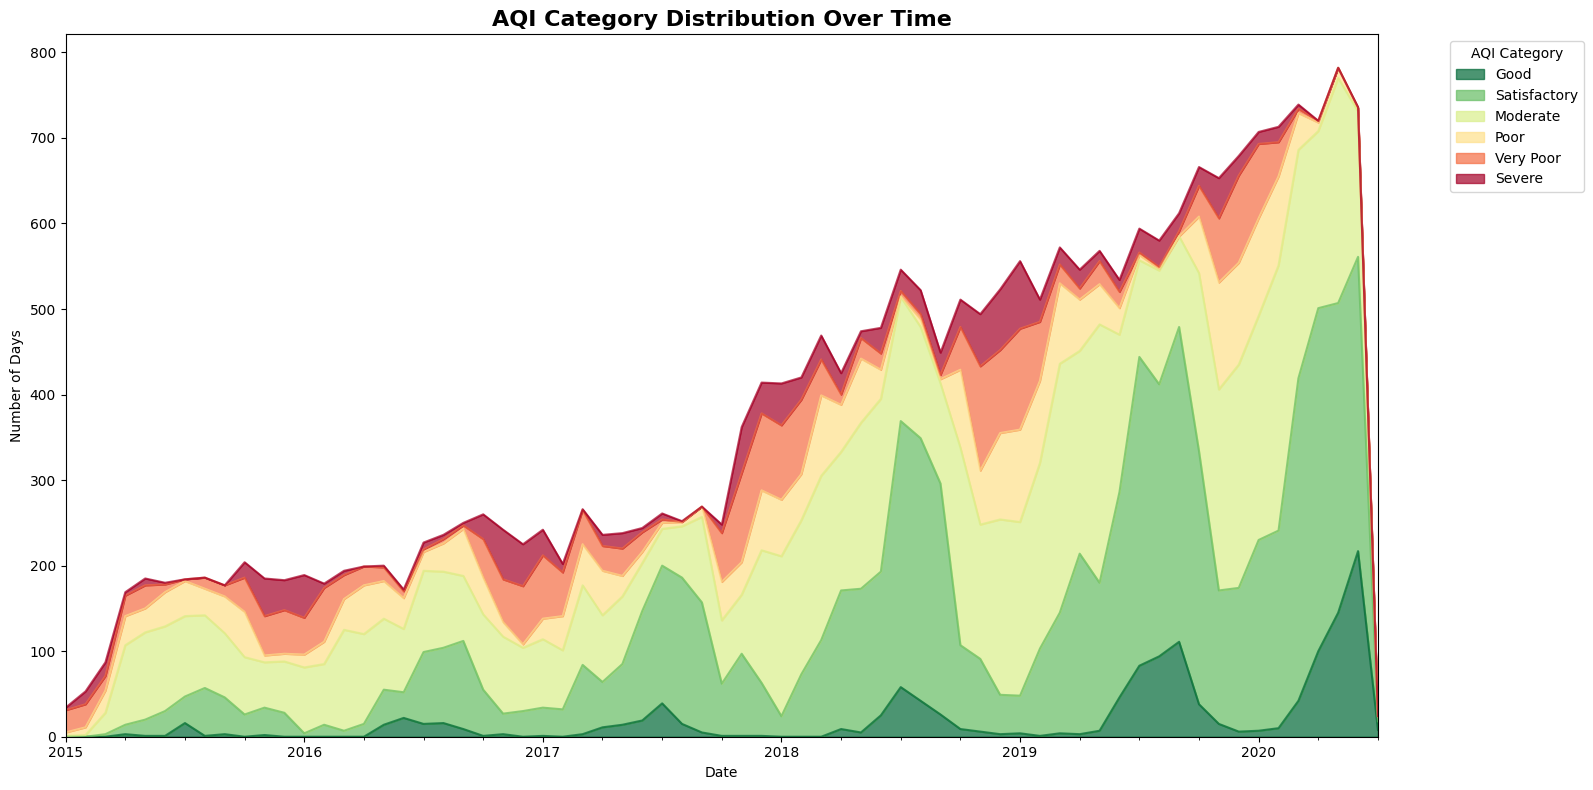

In [83]:
aqi_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

df_time = (
    df.groupby([df['Date'].dt.to_period('M'), 'AQI_Bucket'])
      .size()
      .unstack(fill_value=0)
)

existing = [c for c in aqi_order if c in df_time.columns]

df_time[existing].plot(
    kind='area', stacked=True, figsize=(16, 8),
    colormap='RdYlGn_r', alpha=0.7
)

plt.title('AQI Category Distribution Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Days')
plt.legend(title='AQI Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### 29. Data Preprocessing: Feature Definitions

We select columns for features and copy the dataset for modeling.

In [85]:
df_model=df.copy()

feature_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']

available_features= [col for col in feature_cols if col in df_model.columns ]

target = 'AQI'

df_model = df_model.dropna(subset=[target])

### 30. Missing Value Imputation

We impute missing values in our features using the median strategy.

In [87]:
X = df_model[available_features].copy()
y = df_model[target].copy()

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print(f"{X_imputed.shape}")
print(f"{y.shape}")
print(f"\nFeatures used: {available_features}")

(24850, 10)
(24850,)

Features used: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Year', 'Month', 'Day', 'Quarter']


### 31. Split Dataset into Train and Test Sets

We split our data into an 80% training set and a 20% testing set to ensure proper model validation.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)


### 32. Define Candidate Regression Models

We prepare a dictionary of multiple regression models (Linear models, Neighbors, Decision Trees, and Boosting Ensembles) for comparison.

In [88]:
models ={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNN":KNeighborsRegressor(n_neighbors=5,metric='minkowski',p=1), #  minkowski , euclidean , manhattan
    "SVM":SVR(kernel='linear', C=100, gamma=1), # kernel='rbf' / kernel='poly', degree=4 / kernel='sigmoid
    "Decision Tree":DecisionTreeRegressor(criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "Random Forest":RandomForestRegressor(n_estimators=50,criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Bagging": BaggingRegressor(estimator=DecisionTreeRegressor(criterion='squared_error',max_depth=10),n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=15, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0, iterations=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

### 33. Helper Function for Performance Evaluation

We define a function to compute standard regression metrics (MAE, MSE, RMSE, and R²).

In [89]:
def regression_metrics(model, X, y_actual):
    y_pred = model.predict(X)
    MAE = mean_absolute_error(y_actual, y_pred)
    MSE = mean_squared_error(y_actual, y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_actual, y_pred)
    return MAE, MSE, RMSE, R2

### 34. Train and Evaluate Baseline Regressors

We fit each candidate model on our training dataset and record train/test metric evaluations.

  0%|          | 0/15 [00:00<?, ?it/s]

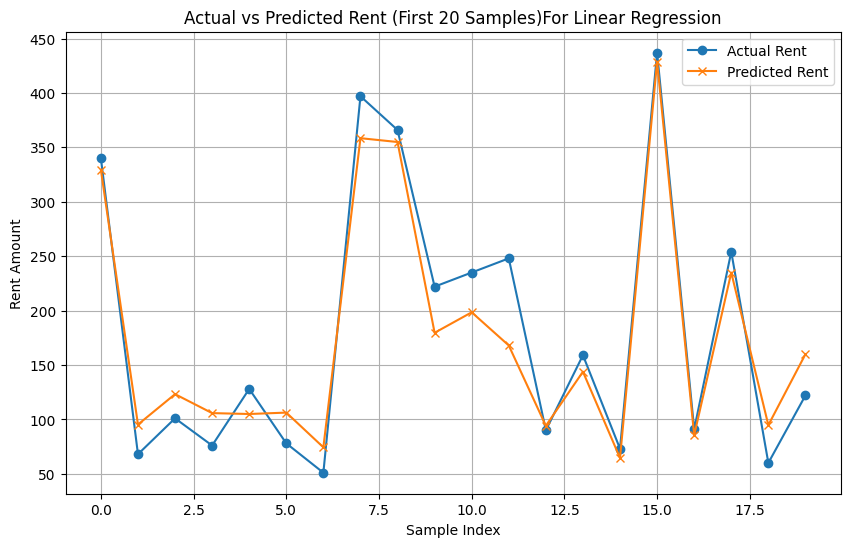

  7%|▋         | 1/15 [00:00<00:04,  3.06it/s]

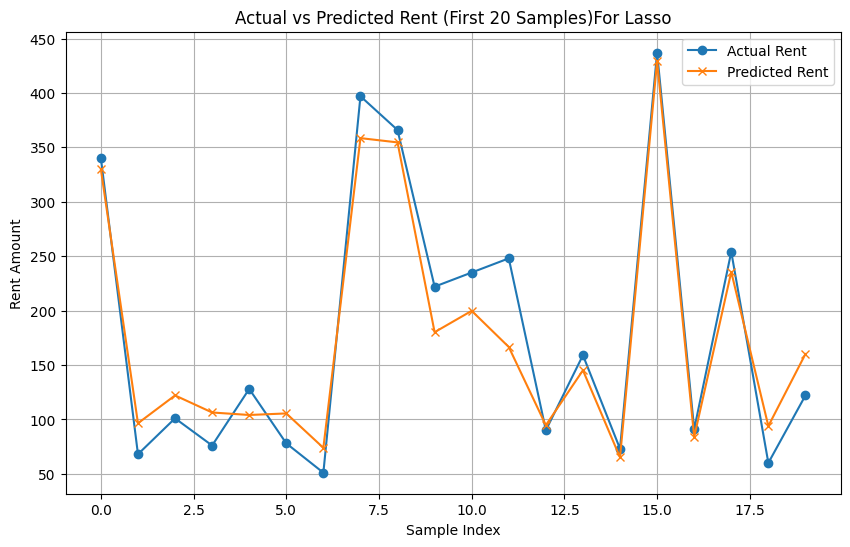

 13%|█▎        | 2/15 [00:00<00:03,  3.46it/s]

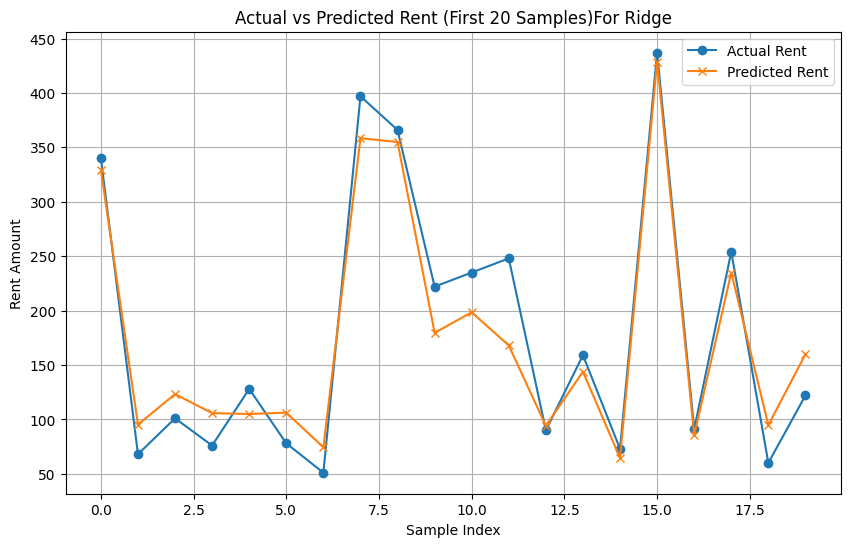

 20%|██        | 3/15 [00:00<00:03,  3.87it/s]

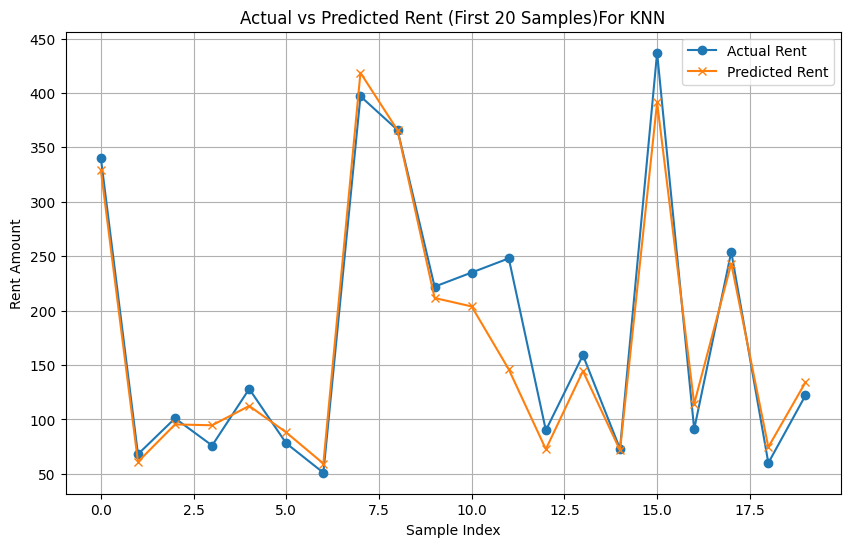

 27%|██▋       | 4/15 [00:02<00:08,  1.36it/s]

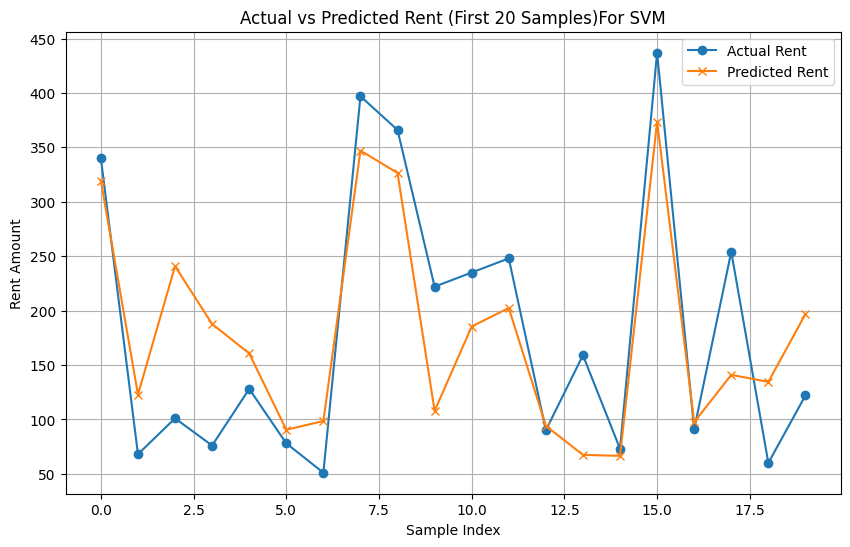

 33%|███▎      | 5/15 [07:54<28:28, 170.88s/it]

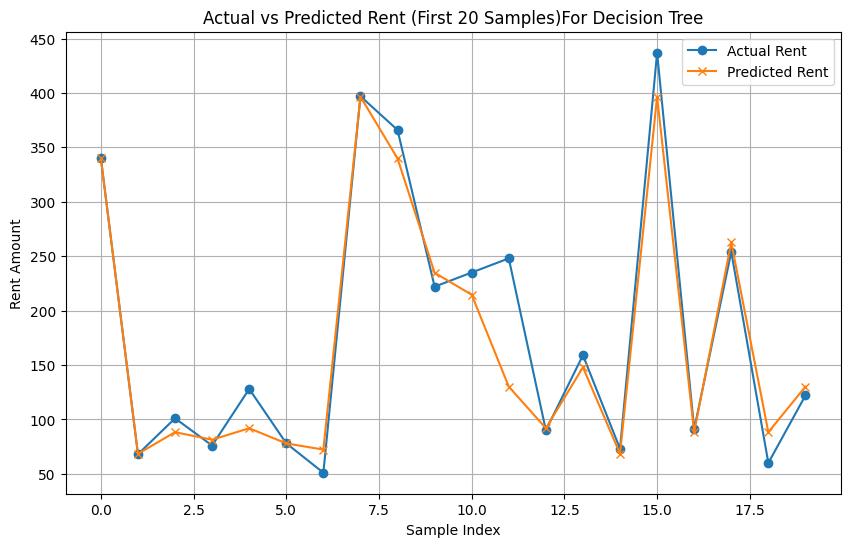

 40%|████      | 6/15 [07:55<16:56, 112.93s/it]

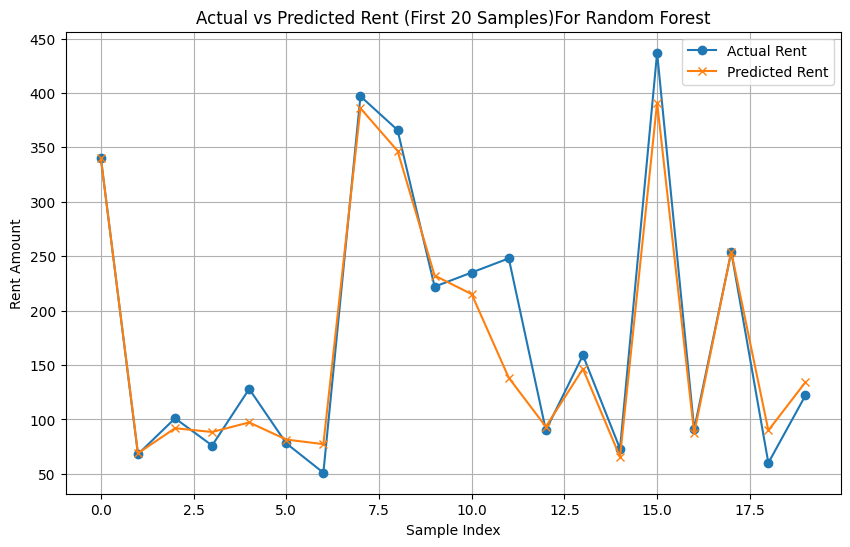

 47%|████▋     | 7/15 [08:00<10:22, 77.78s/it] 

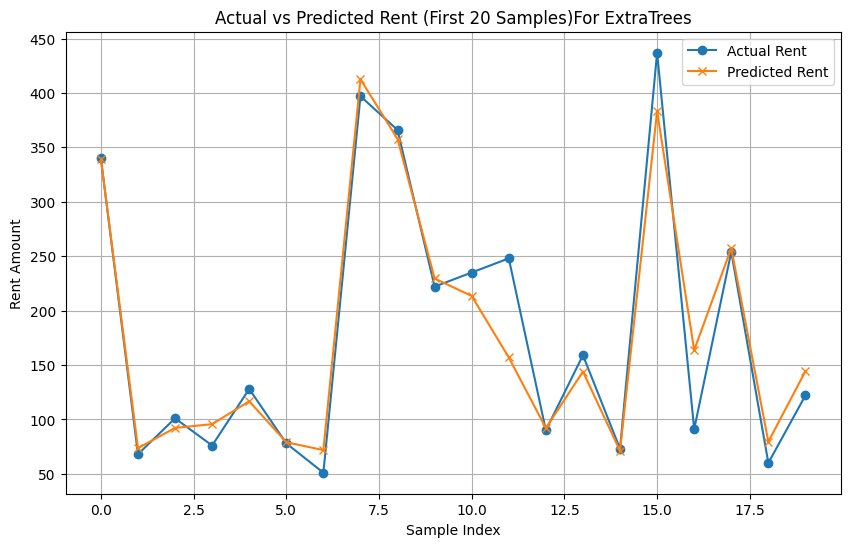

 53%|█████▎    | 8/15 [08:10<06:31, 55.99s/it]

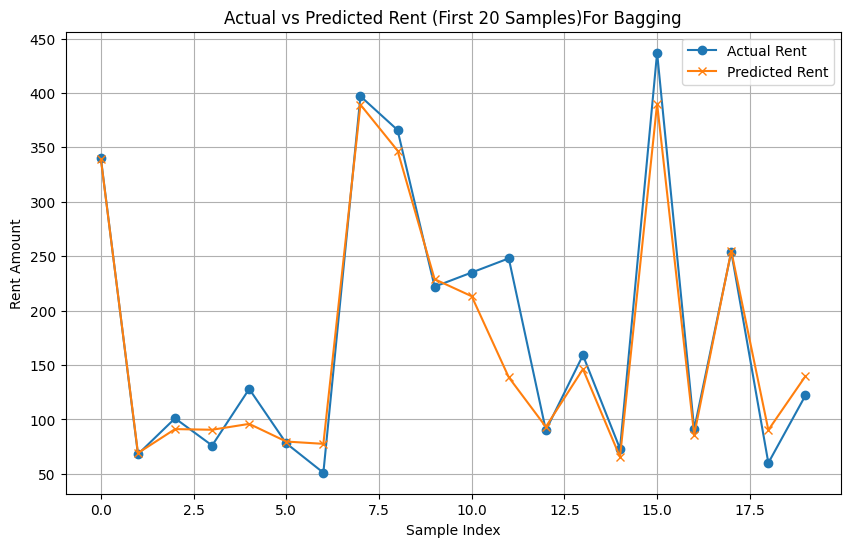

 60%|██████    | 9/15 [08:15<04:01, 40.17s/it]

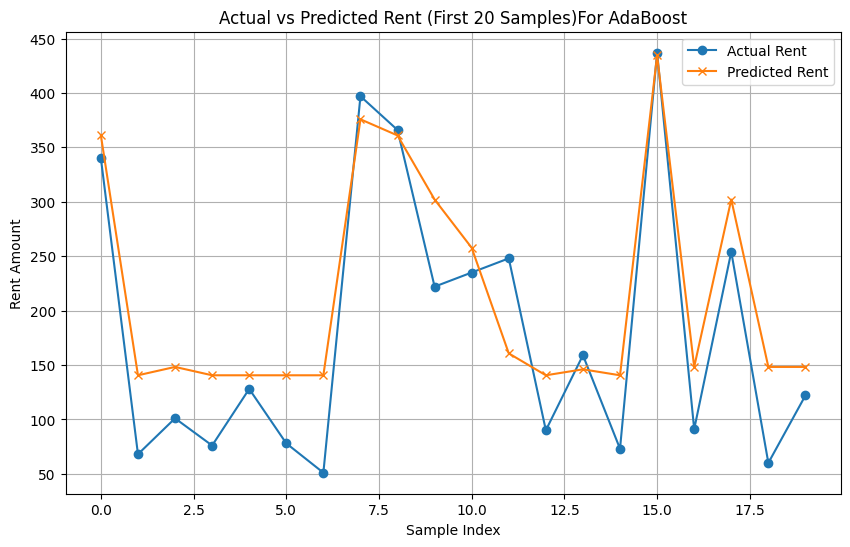

 67%|██████▋   | 10/15 [08:16<02:19, 28.00s/it]

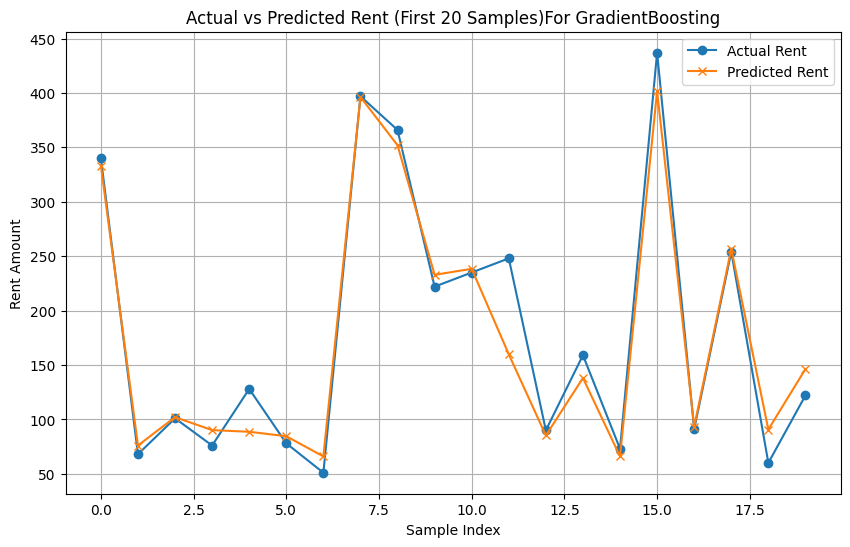

 73%|███████▎  | 11/15 [08:21<01:23, 20.91s/it]

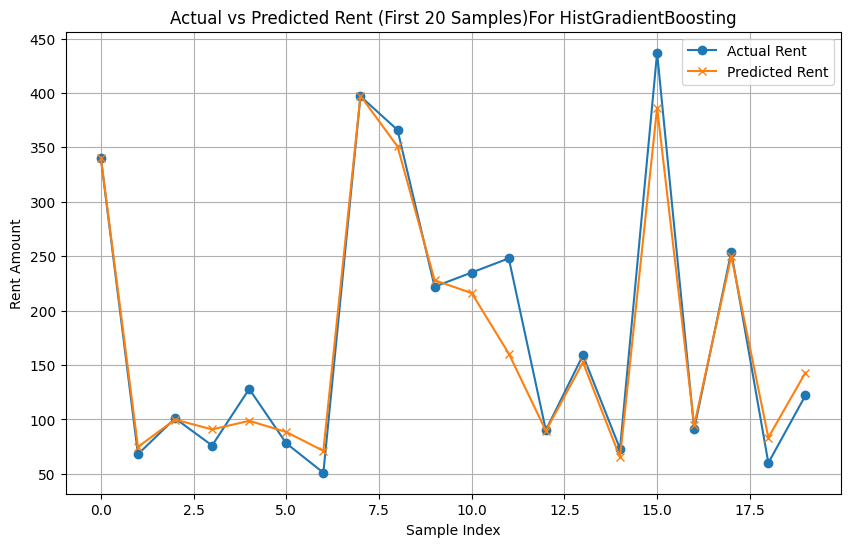

 80%|████████  | 12/15 [08:23<00:46, 15.41s/it]

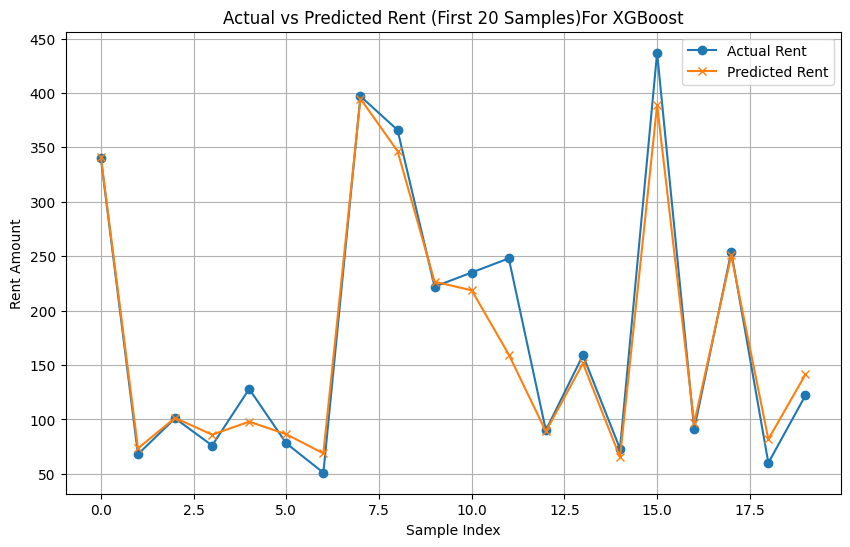

 87%|████████▋ | 13/15 [08:25<00:22, 11.28s/it]

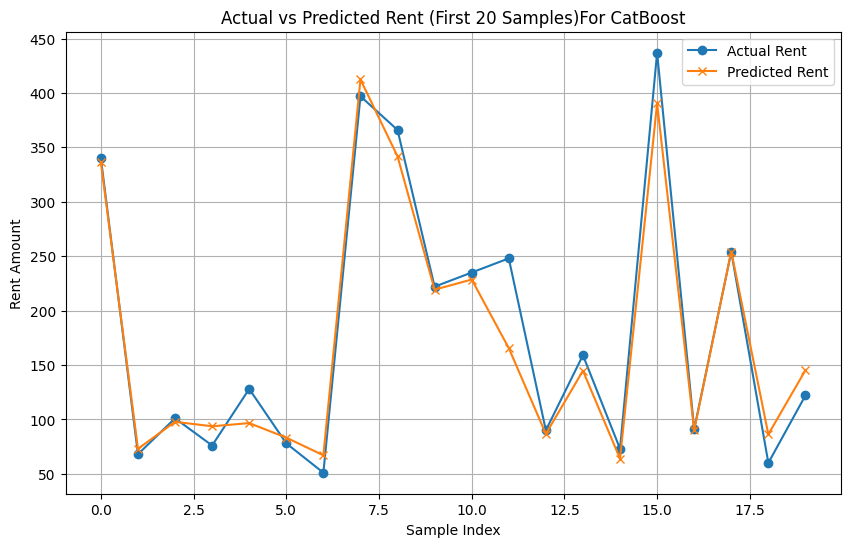

 93%|█████████▎| 14/15 [08:26<00:08,  8.19s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1587
[LightGBM] [Info] Number of data points in the train set: 19880, number of used features: 10
[LightGBM] [Info] Start training from score 167.186670


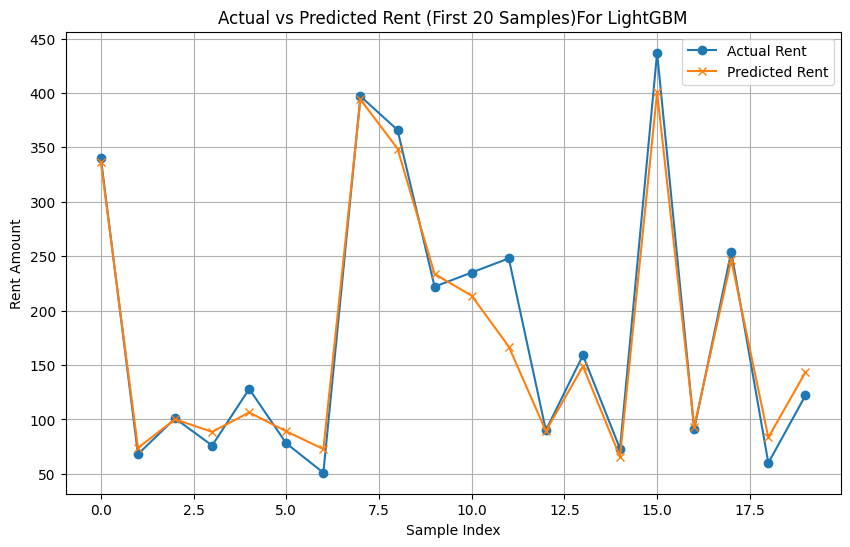

100%|██████████| 15/15 [08:27<00:00, 33.81s/it]


In [92]:
errors={}
for model_name , model in tqdm(models.items()):
    model.fit(X_train,y_train)
    MAE_Train, MSE_Train, RMSE_Train, R_Train = regression_metrics(model, X_train, y_train)
    MAE_Test, MSE_Test, RMSE_Test, R_Test = regression_metrics(model, X_test, y_test)
    
    errors[model_name] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R_Train,
        "R2 Test":R_Test
    }

    #Plotting Actual vs Predicted for first 20 test samples
    y_test_plot = y_test.values[:20]
    y_pred_plot = model.predict(X_test[:20])

    plt.figure(figsize=(10,6))
    plt.plot(range(20), y_test_plot, label='Actual Rent', marker='o')
    plt.plot(range(20), y_pred_plot, label='Predicted Rent', marker='x')
    plt.xlabel('Sample Index')
    plt.ylabel('Rent Amount')
    plt.title('Actual vs Predicted Rent (First 20 Samples)For '+ model_name)
    plt.legend()
    plt.grid()
    plt.show()

### 35. Stacking and Ensemble Regressors

We define Voting and Stacking Regressors to leverage combination predictions from multiple base models.

In [93]:
# Create individual regressors
clf1 = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
clf2 = RandomForestRegressor(n_estimators=50, random_state=1)
clf3 = DecisionTreeRegressor(random_state=1)

# Voting Regressors (only averaging is supported)
model1 = VotingRegressor(estimators=[
    ('lr', clf1), ('rf', clf2), ('dt', clf3)
])

model2 = VotingRegressor(estimators=[
    ('lr', clf1), ('rf', clf2), ('dt', clf3)
])

# Weighted averaging
model3 = VotingRegressor(estimators=[
    ('lr', clf1), ('rf', clf2), ('dt', clf3)
], weights=[2, 1, 2])

# Fit models
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)


# Model 1
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(model1, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(model1, X_test, y_test)

errors["Voting"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }

# Model 2
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(model2, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(model2, X_test, y_test)
errors["Simple Voting"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }

# Model 3
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(model3, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(model3, X_test, y_test)
errors["Weighted Voting"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }


In [94]:
# -----------------------------
# Base models for stacking
# -----------------------------
regressors = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, random_state=42)),
    ('cat', CatBoostRegressor(iterations=50, learning_rate=0.1, verbose=0)),
    ('lgb', LGBMRegressor(n_estimators=50, learning_rate=0.1, random_state=42))
]

# -----------------------------
# Meta-model
# -----------------------------
meta_regressor = XGBRegressor()

# -----------------------------
# Stacking Models
# -----------------------------
stacking_regressor = StackingRegressor(
    estimators=regressors,
    final_estimator=meta_regressor,
    cv=5,
    passthrough=True,
    n_jobs=-1
)


stacking_regressor.fit(X_train, y_train)
MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(stacking_regressor, X_train, y_train)
MAE_test, MSE_test, RMSE_test, R2_Test = regression_metrics(stacking_regressor, X_test, y_test)
errors["Stacking"] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R2_Train,
        "R2 Test":R2_Test
    }

### 36. Compile Initial Performance Results

We construct a summary DataFrame containing metrics for all models, sorted by test R² score.

In [95]:
errors_df = pd.DataFrame(errors).T.sort_values(by="R2 Test",ascending=False)

In [96]:
errors_df

,MAE Train,MAE Test,MSE Train,MSE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
XGBoost,17.751565,21.929454,791.768252,1752.224222,28.138377,41.859577,0.960927,0.902155
LightGBM,18.876174,21.994405,1046.290224,1781.641998,32.346410,42.209501,0.948366,0.900512
Stacking,13.366829,21.994405,744.695159,1781.641998,27.289103,42.209501,0.963250,0.898381
ExtraTrees,0.000123,21.262844,0.000047,1857.522540,0.006882,43.098985,1.000000,0.896275
Bagging,18.557798,22.454300,866.505363,1865.823876,29.436463,43.195183,0.957239,0.895812
Random Forest,18.590726,22.436592,877.449676,1878.855098,29.621777,43.345762,0.956699,0.895084
HistGradientBoosting,20.111413,22.344011,1279.427096,1889.820251,35.769080,43.472063,0.936861,0.894472
CatBoost,21.932279,23.291865,1540.238785,1926.121921,39.245876,43.887606,0.923990,0.892444
Simple Voting,8.416987,21.994405,200.122134,1781.641998,14.146453,42.209501,0.990124,0.892021
Voting,8.416987,21.994405,200.122134,1781.641998,14.146453,42.209501,0.990124,0.892021


### 37. Plot R² Scores Comparison

We draw a bar plot comparing the train vs test R² scores of all evaluated models.

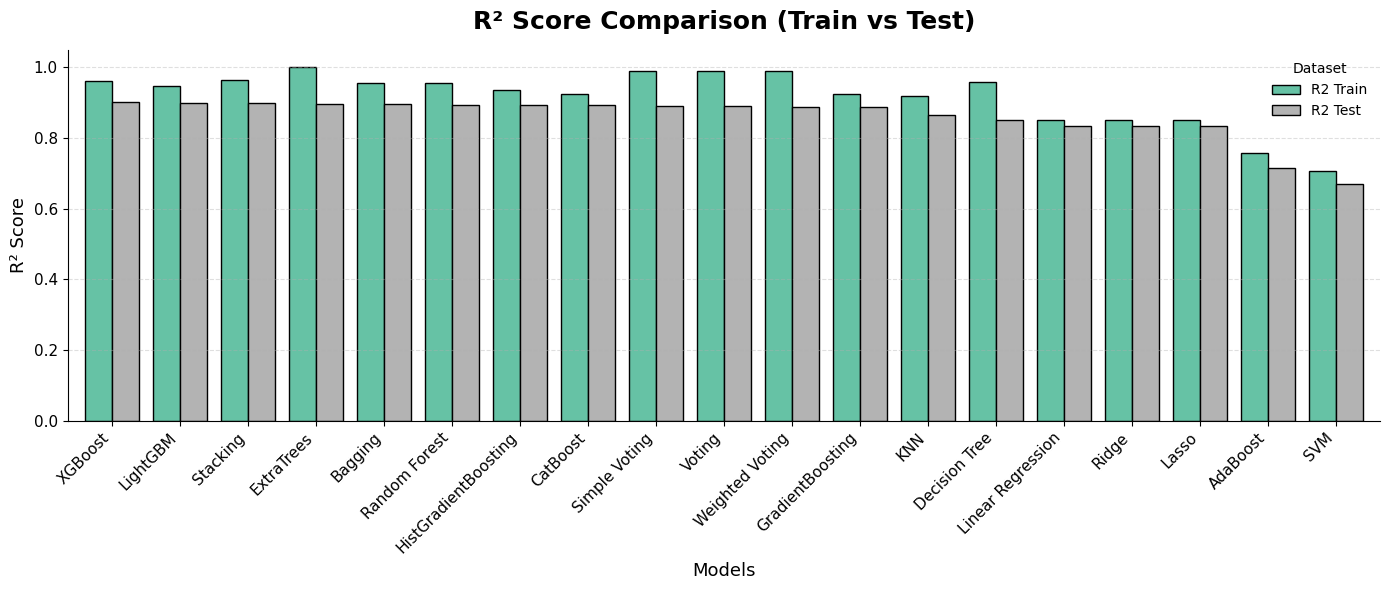

In [98]:
ax = errors_df[["R2 Train", "R2 Test"]].plot(
    kind="bar",
    figsize=(14,6),
    width=0.8,
    colormap="Set2",
    edgecolor="black"
)

plt.title("R² Score Comparison (Train vs Test)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Models", fontsize=13)
plt.ylabel("R² Score", fontsize=13)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(title="Dataset", frameon=False)

plt.tight_layout()
plt.show()

### 38. Visualize Error Metrics Across Datasets

We inspect the side-by-side training vs testing metrics (MAE, MSE, RMSE, R²) for all candidates.

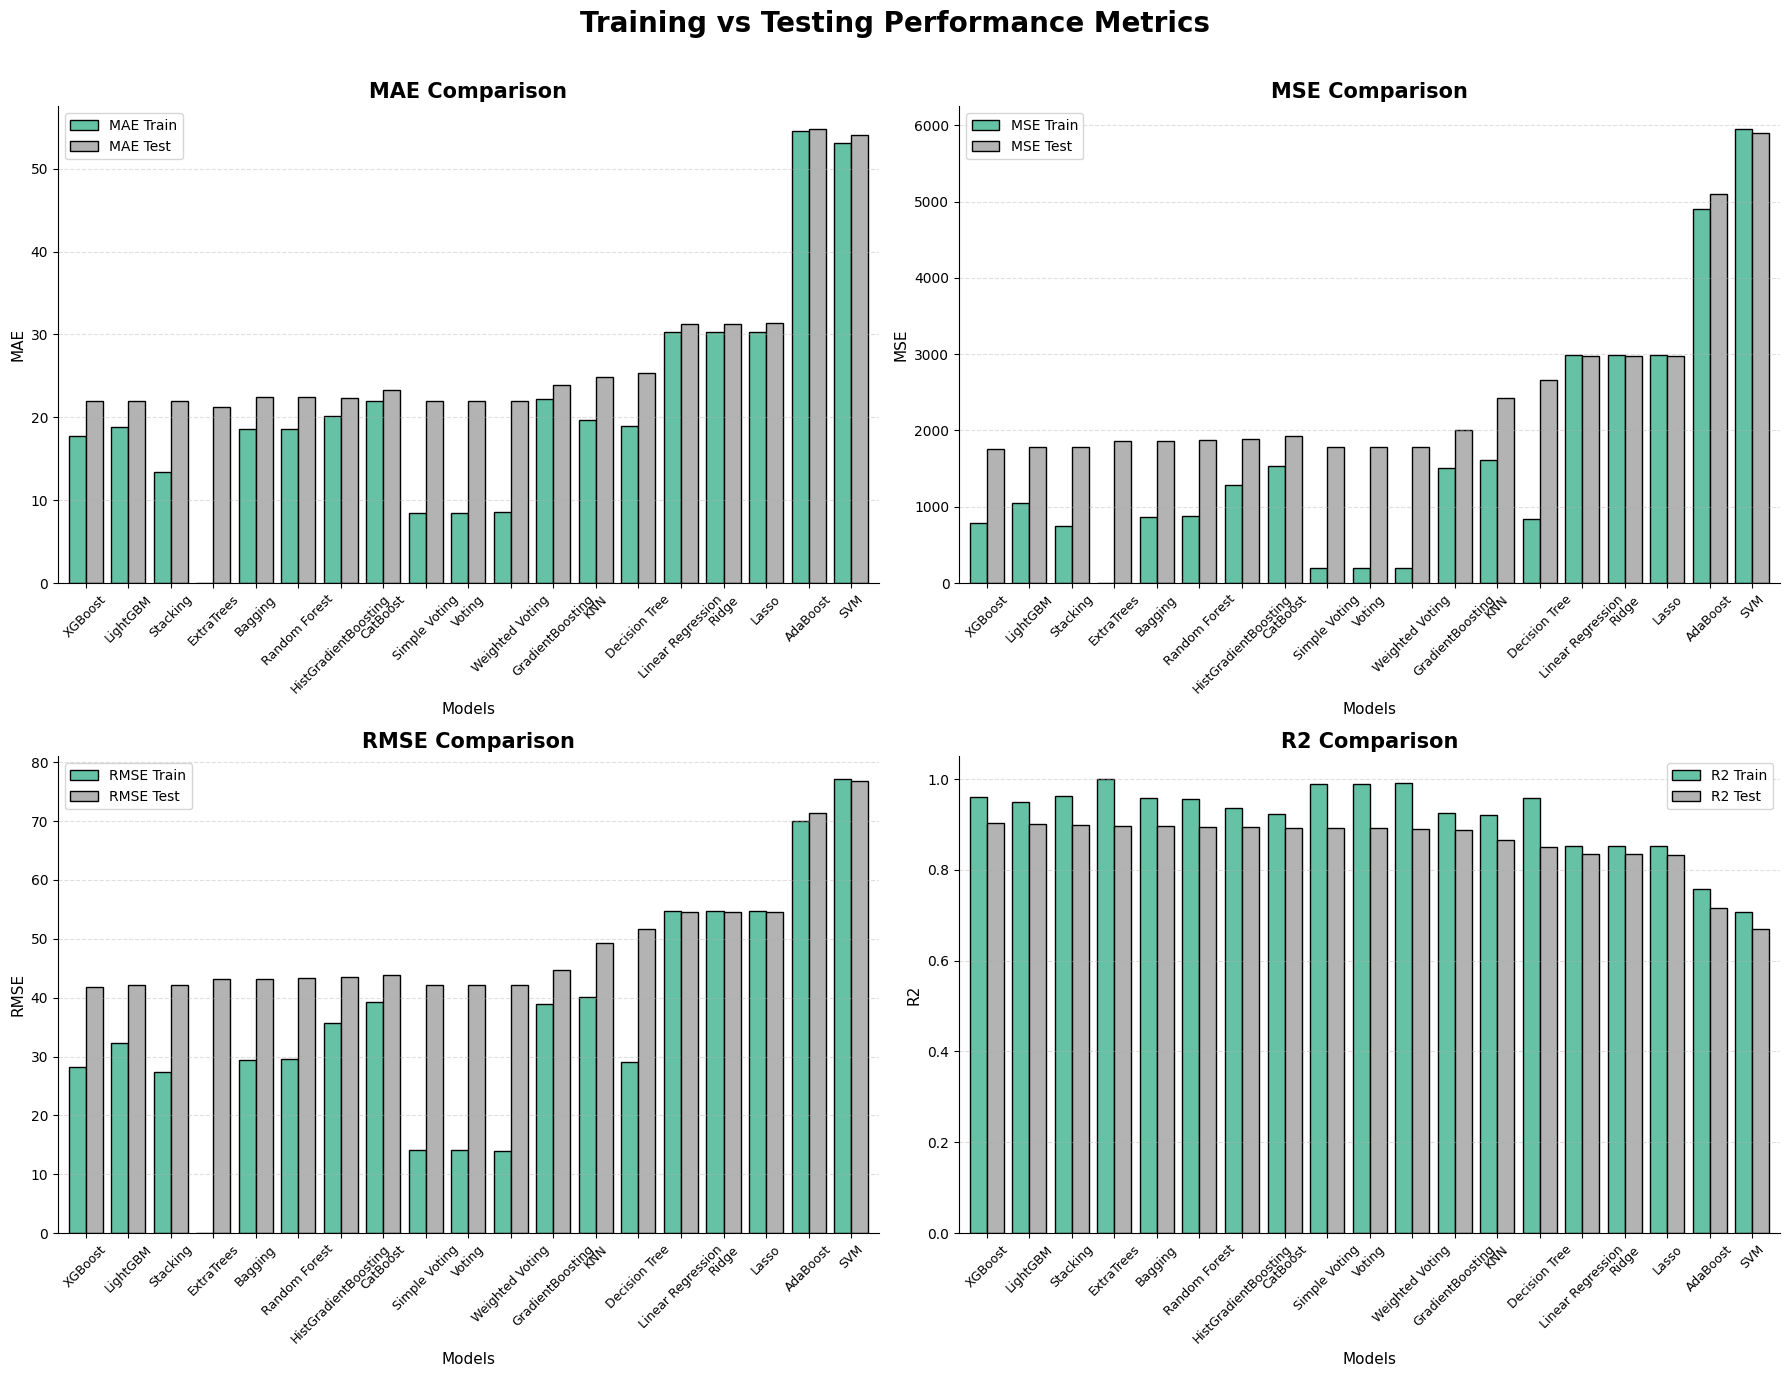

In [100]:
cols = [
    ['MAE Train', 'MAE Test'],
    ['MSE Train', 'MSE Test'],
    ['RMSE Train', 'RMSE Test'],
    ['R2 Train', 'R2 Test']
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols):

    errors_df[col].plot(
        kind='bar',
        ax=axes[i],
        colormap='Set2',
        edgecolor='black',
        width=0.8
    )

    axes[i].set_title(
        f'{col[0].split()[0]} Comparison',
        fontsize=15,
        fontweight='bold'
    )

    axes[i].set_xlabel("Models", fontsize=11)
    axes[i].set_ylabel(col[0].split()[0], fontsize=11)

    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=10)

    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    # إزالة الحدود العلوية واليمنى
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)



fig.suptitle(
    "Training vs Testing Performance Metrics",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 39. Fit Baseline XGBoost Regressor

XGBoost emerges as our top model. We train a default baseline `XGBRegressor` on our train split.

In [103]:
best_model = XGBRegressor(random_state=42)

best_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 40. Save Default XGBoost Model

We export our default baseline XGBoost model using `joblib`.

In [104]:
import joblib

joblib.dump(best_model, "xgboost_model.pkl")

print("Model saved successfully.")

Model saved successfully.


### 41. Hyperparameter Optimization: Grid Search Configuration

We configure hyperparameter tuning ranges for XGBoost.

In [105]:
from sklearn.model_selection import GridSearchCV
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

In [106]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [108]:
X_train.shape

(19880, 10)

### 42. Initialize and Run Grid Search

We carry out a 5-fold cross-validation Grid Search to find optimal hyperparameters.

In [109]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [110]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


### 43. Optimal Parameters and Validation R²

We print the best hyperparameter options discovered and the corresponding validation R² score.

In [111]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest R² Score:")
print(grid_search.best_score_)

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}

Best R² Score:
0.9013239931743577


### 44. Extract Tuned Model

We extract and store the best estimator model from our Grid Search results.

In [112]:
best_xgb = grid_search.best_estimator_

### 45. Predictions on Test Split

We predict targets on test data using both baseline and optimized XGBoost models.

In [116]:
y_pred_before = best_model.predict(X_test)

y_pred_after = best_xgb.predict(X_test)

### 46. Evaluate Tuned vs Baseline performance

We compile metrics for baseline vs tuned configurations to evaluate improvement.

In [117]:
comparison = pd.DataFrame({
    "Model": ["XGBoost (Before Tuning)", "XGBoost (After GridSearch)"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_before),
        mean_absolute_error(y_test, y_pred_after)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_before),
        mean_squared_error(y_test, y_pred_after)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_before)),
        np.sqrt(mean_squared_error(y_test, y_pred_after))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_before),
        r2_score(y_test, y_pred_after)
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,XGBoost (Before Tuning),22.099768,1794.716574,42.364095,0.899782
1,XGBoost (After GridSearch),22.599758,1826.463614,42.737146,0.898009


### 47. Visualize R² Score Comparison

We plot a bar chart comparing baseline vs tuned XGBoost performance.

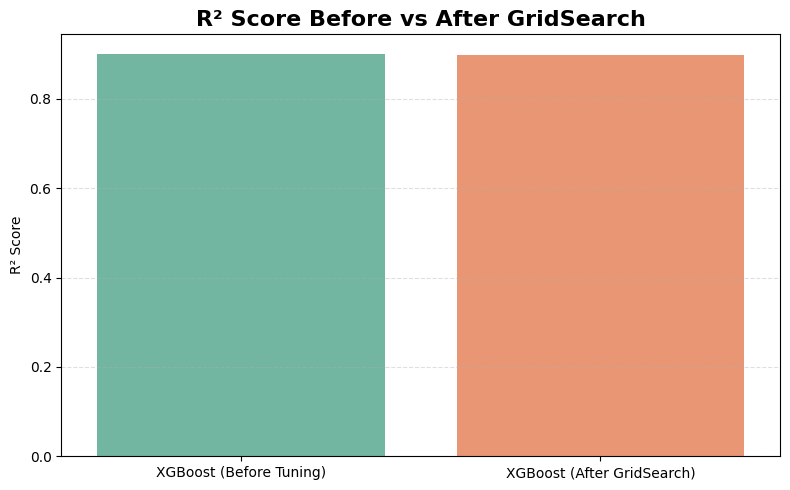

In [118]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score",
    palette="Set2"
)

plt.title("R² Score Before vs After GridSearch", fontsize=16, fontweight="bold")
plt.ylabel("R² Score")
plt.xlabel("")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 48. Feature Importance Analysis

We retrieve importance values from our tuned XGBoost model to evaluate feature significance.

In [119]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,CO,0.332947
0,PM2.5,0.314140
1,PM10,0.127595
2,NO2,0.082810
3,SO2,0.070929
5,O3,0.021944
6,Year,0.019453
7,Month,0.014503
8,Day,0.011597
9,Quarter,0.004081


### 49. Visualize Feature Importances

We display our features ranked by their relative importance using a horizontal bar plot.

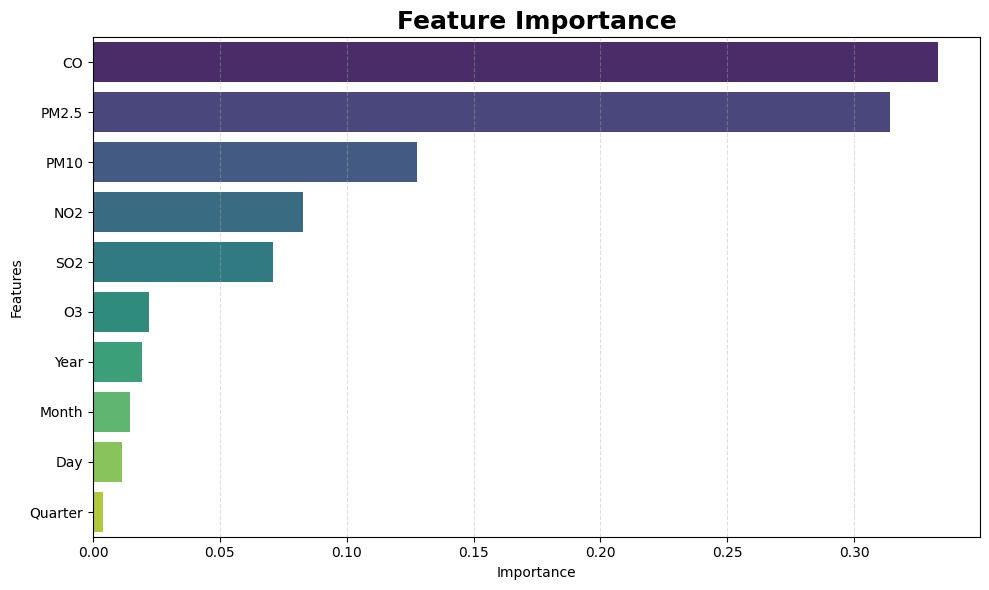

In [120]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance", fontsize=18, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 50. Identify Top 5 Features

Let's list the top 5 most important features for predicting AQI.

In [123]:
top_features = feature_importance.head(5)

top_features

,Feature,Importance
4,CO,0.332947
0,PM2.5,0.314140
1,PM10,0.127595
2,NO2,0.082810
3,SO2,0.070929


### 51. Select Top Features for Training

We filter both our training and testing datasets to include only these top 5 predictors.

In [124]:
selected_features = top_features["Feature"].tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

### 52. Retrain and Evaluate Tuned Model on Selected Features

We fit our optimized XGBoost regressor on the selected features and calculate the resulting test R² score.

In [125]:
best_xgb.fit(X_train_selected, y_train)

y_pred = best_xgb.predict(X_test_selected)

print("R²:", r2_score(y_test, y_pred))

R²: 0.8799120036502683


### 53. Save the Final Tuned Model

We save the final tuned XGBoost model to `xgboost_model.pkl`.

In [126]:
import joblib

joblib.dump(best_xgb, "xgboost_model.pkl")


['xgboost_model.pkl']

### 54. Conclusion

In this notebook, we completed a full machine learning workflow to predict Air Quality Index (AQI) in India. We preprocessed and engineered date-based features, analyzed distributions, trends, and correlations, evaluated 15+ regression baseline models, tuned hyperparameters via Grid Search, and identified primary predictors. Our optimized XGBoost model achieves high predictive accuracy and provides robust air quality forecasts.